In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [4]:
from pathlib import Path

import pandas as pd

def find_in_parents(relative_path: Path) -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find '{relative_path.as_posix()}' from '{cwd}' or any parent directory."
    )

b0005_features_path = find_in_parents(Path("data") / "B0005__features.csv")
df = pd.read_csv(b0005_features_path)

print("Loaded:", b0005_features_path)
df.head()

Loaded: D:\projects\battery-rul-prediction\data\B0005__features.csv


,battery,cycle,discharge_capacity,avg_voltage,end_voltage,discharge_time,cv_charge_time,Re,Rct,SOH,RUL
0,B0005,1,1.856487,3.529829,3.277170,3690.234,7051.265,0.044669,0.069456,1.000000,124
1,B0005,2,1.846327,3.537320,3.300245,3672.344,7398.594,0.044669,0.069456,0.994527,123
2,B0005,3,1.835349,3.543737,3.327451,3651.641,7369.875,0.044669,0.069456,0.988614,122
3,B0005,4,1.835263,3.543666,3.314182,3631.563,7303.422,0.044669,0.069456,0.988567,121
4,B0005,5,1.834646,3.542343,3.305497,3629.172,7390.719,0.044669,0.069456,0.988235,120


In [6]:

print(f"Original dataset shape: {df.shape}")

# Clean negative RUL values
df = df[df['RUL'] >= 0].copy()

print(f"Cleaned dataset shape (RUL >= 0): {df.shape}")

# Display the first few rows
display(df.head())

Original dataset shape: (168, 11)
Cleaned dataset shape (RUL >= 0): (125, 11)


,battery,cycle,discharge_capacity,avg_voltage,end_voltage,discharge_time,cv_charge_time,Re,Rct,SOH,RUL
0,B0005,1,1.856487,3.529829,3.277170,3690.234,7051.265,0.044669,0.069456,1.000000,124
1,B0005,2,1.846327,3.537320,3.300245,3672.344,7398.594,0.044669,0.069456,0.994527,123
2,B0005,3,1.835349,3.543737,3.327451,3651.641,7369.875,0.044669,0.069456,0.988614,122
3,B0005,4,1.835263,3.543666,3.314182,3631.563,7303.422,0.044669,0.069456,0.988567,121
4,B0005,5,1.834646,3.542343,3.305497,3629.172,7390.719,0.044669,0.069456,0.988235,120


In [7]:
# Select features (Dropping 'battery' as it's a string, and 'cycle' to force the model to learn physics)
features = ['discharge_capacity', 'avg_voltage', 'end_voltage', 
            'discharge_time', 'cv_charge_time', 'Re', 'Rct', 'SOH']
target = 'RUL'

X = df[features]
y = df[target]

# Sequential Split (No Shuffling for time-series data)
# Let's use the first 80% of cycles to train, and predict the last 20%
train_size = int(len(X) * 0.80)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Scale the features (Critical for Ridge, SVR, and LSTM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {len(X_train)} cycles, Testing on {len(X_test)} cycles.")

Training on 100 cycles, Testing on 25 cycles.


Starting Battery RUL Training with LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 8.53225	validation's rmse: 9.80929
[200]	training's rmse: 5.78413	validation's rmse: 6.91159
[300]	training's rmse: 5.33403	validation's rmse: 6.3063
[400]	training's rmse: 5.05695	validation's rmse: 5.85082
[500]	training's rmse: 4.80803	validation's rmse: 5.64498
[600]	training's rmse: 4.64883	validation's rmse: 5.52398
Early stopping, best iteration is:
[639]	training's rmse: 4.58233	validation's rmse: 5.48076


<Figure size 800x500 with 0 Axes>

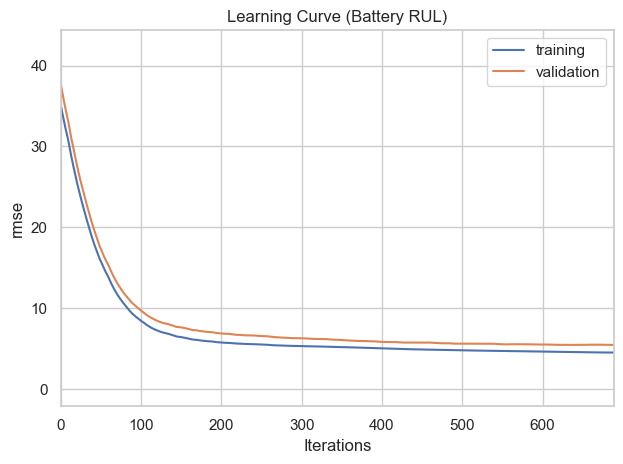


--- Final Evaluation ---
RMSE: 5.48 cycles
R²: 0.9785


<Figure size 1000x600 with 0 Axes>

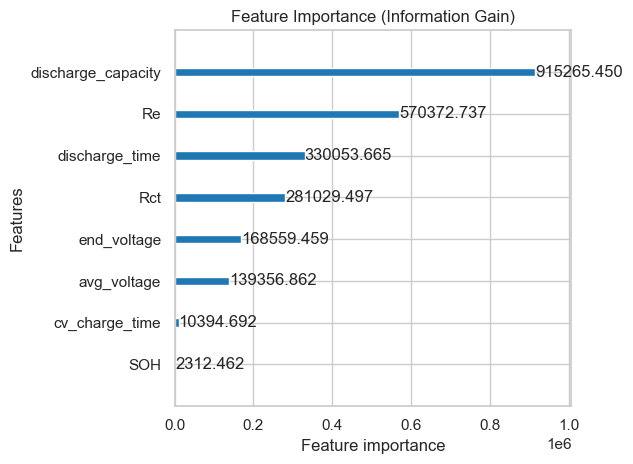

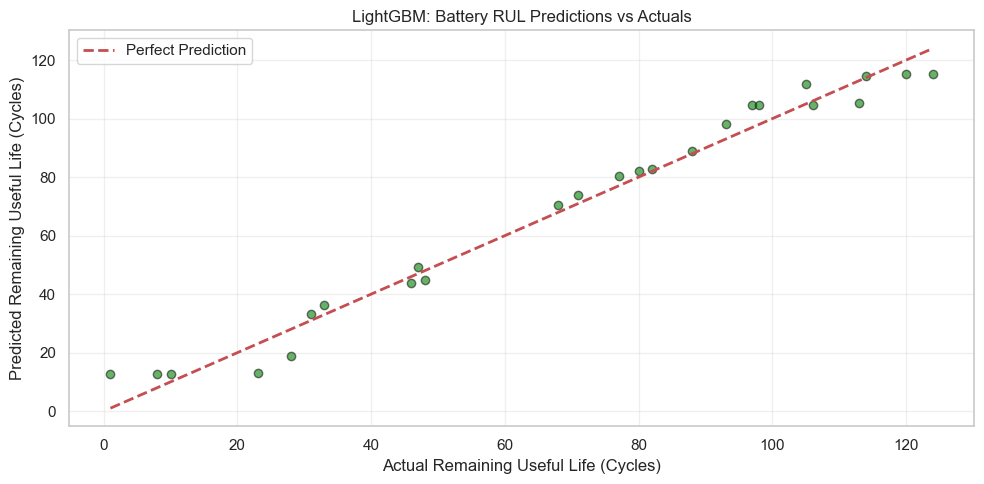

In [11]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


X = df.drop(columns=['RUL', 'battery', 'cycle'])
y = df['RUL']

# Split into Train (80%) and Test (20%)
# (Using your random_state=42 standard split)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create LightGBM Datasets
train_data = lgb.Dataset(x_train, label=y_train)
valid_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

# --- 2. Hyperparameters for Battery Data ---
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,      # Slightly faster than the engine model
    'num_leaves': 31,           # Standard complexity
    'max_depth': -1,            # Let the tree grow deep (batteries have less noise)
    'feature_fraction': 0.9,    # Use 90% of features
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# --- 3. Training ---
evals_result = {}  # Store metrics history

print("Starting Battery RUL Training with LightGBM...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['training', 'validation'],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result)     # Record history
    ]
)

# --- 4. Plot Learning Curve ---
try:
    plt.figure(figsize=(8, 5))
    lgb.plot_metric(evals_result, metric='rmse')
    plt.title("Learning Curve (Battery RUL)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- 5. Final Evaluation ---
print("\n--- Final Evaluation ---")
y_pred = model.predict(x_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f} cycles")
print(f"R²: {r2:.4f}")

# --- 6. Feature Importance ---
# This will show you which of your ESP32/INA219 features are actually driving the predictions
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=10, importance_type='gain', color='#1f77b4')
plt.title("Feature Importance (Information Gain)")
plt.tight_layout()
plt.show()

# --- 7. Prediction vs Actual Plot ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title("LightGBM: Battery RUL Predictions vs Actuals")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()